In [32]:
import pandas as pd

df = pd.read_csv('C:/Users/grace/Desktop/amphan_track.csv', low_memory=False)
df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())


['sid', 'season', 'number', 'basin', 'subbasin', 'name', 'iso_time', 'nature', 'lat', 'lon', 'wmo_wind', 'wmo_pres', 'wmo_agency', 'track_type', 'dist2land', 'landfall', 'iflag', 'usa_agency', 'usa_atcf_id', 'usa_lat', 'usa_lon', 'usa_record', 'usa_status', 'usa_wind', 'usa_pres', 'usa_sshs', 'usa_r34_ne', 'usa_r34_se', 'usa_r34_sw', 'usa_r34_nw', 'usa_r50_ne', 'usa_r50_se', 'usa_r50_sw', 'usa_r50_nw', 'usa_r64_ne', 'usa_r64_se', 'usa_r64_sw', 'usa_r64_nw', 'usa_poci', 'usa_roci', 'usa_rmw', 'usa_eye', 'tokyo_lat', 'tokyo_lon', 'tokyo_grade', 'tokyo_wind', 'tokyo_pres', 'tokyo_r50_dir', 'tokyo_r50_long', 'tokyo_r50_short', 'tokyo_r30_dir', 'tokyo_r30_long', 'tokyo_r30_short', 'tokyo_land', 'cma_lat', 'cma_lon', 'cma_cat', 'cma_wind', 'cma_pres', 'hko_lat', 'hko_lon', 'hko_cat', 'hko_wind', 'hko_pres', 'newdelhi_lat', 'newdelhi_lon', 'newdelhi_grade', 'newdelhi_wind', 'newdelhi_pres', 'newdelhi_ci', 'newdelhi_dp', 'newdelhi_poci', 'reunion_lat', 'reunion_lon', 'reunion_type', 'reunion_w

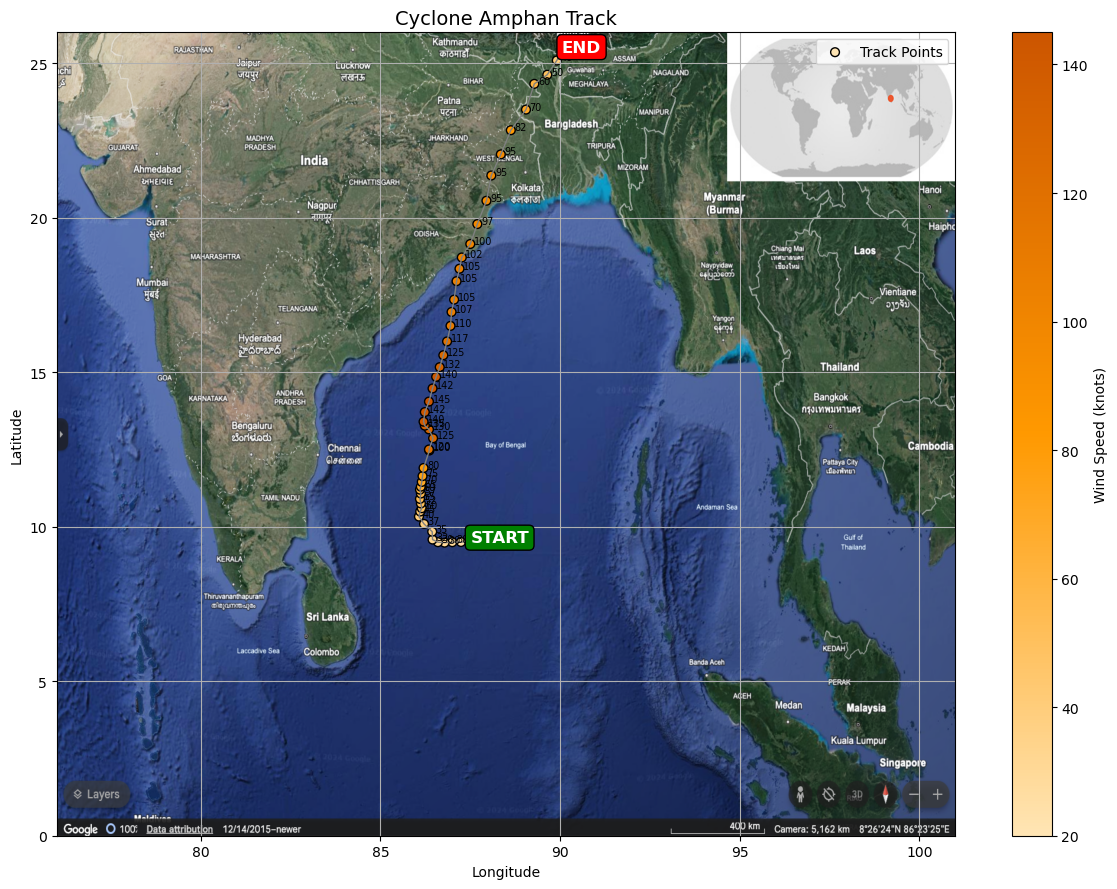

In [37]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

# === Load Satellite Image ===
img = mpimg.imread('C:/Users/grace/Desktop/googlearthimage.png')

# === Set Geographic Extent (make sure this matches your image bounds) ===
extent = [76, 101, 0, 26]

# === Load Cyclone Track Data ===
df = pd.read_csv('C:/Users/grace/Desktop/amphan_track.csv', low_memory=False)

# Normalize column names
df.columns = df.columns.str.strip().str.lower()

# Filter for Cyclone Amphan
df = df[df['name'].str.upper() == 'AMPHAN']

# Convert coordinates and wind speed to numeric
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
df['wind'] = pd.to_numeric(df['usa_wind'], errors='coerce')  # Use USA wind data

# Drop missing values
df = df.dropna(subset=['lat', 'lon', 'wind'])

# === Plotting ===
plt.figure(figsize=(12, 9))
plt.imshow(img, extent=extent, aspect='auto')

# Scatter with color mapped to wind speed
from matplotlib.colors import LinearSegmentedColormap

# Define custom orange colormap (light to dark orange)
orange_cmap = LinearSegmentedColormap.from_list("orange_map", ["#ffe5b4", "#ff9900", "#cc5500"])

# Use the custom colormap in scatter
sc = plt.scatter(df['lon'], df['lat'], c=df['wind'], cmap=orange_cmap, s=40, edgecolors='black', label='Track Points')

plt.plot(df['lon'], df['lat'], color='gray', linewidth=1)

# Annotate wind speed at each point
for i, row in df.iterrows():
    plt.text(row['lon'] + 0.1, row['lat'], f"{int(row['wind'])}", fontsize=7, color='black')

# Start and End Annotations
plt.text(df['lon'].iloc[0], df['lat'].iloc[0], 'Start', fontsize=10, color='green')
plt.text(df['lon'].iloc[-1], df['lat'].iloc[-1], 'End', fontsize=10, color='red')

# Add Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Wind Speed (knots)')

# Labels and layout
plt.title("Cyclone Amphan Track Colored by Wind Speed", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()
